## Square root of a number

The method of tangents computes the root of a function $f(x)$ by applying:

\begin{cases}
    x_{i + 1} = x_{i} - \frac{f(x_{i})}{f'(x_{i})} \\
    x_0 \in \left[ a, b \right]
\end{cases}

If we apply this to $f(x) = x^{2} - k$, we obtain an iterative formula to get the square root of $k$ (known as Heron's formula):

$$
    x_{i + 1} = \frac{1}{2} \, \left( x_{i} + \frac{k}{x_{i}} \right)
$$

Let's implement it manually to compute the square root of $2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def root(k, ab, N, eps, tol): # Implements the Heron's formula

    a, b = ab # initial range [a, b]

    f = lambda x: x ** 2 - k # x^2 - k = 0

    x = (a + b) / 2.0 # Initial value of x (x0)
    err = abs((x ** 2 - k) / (2 * x)) # Initial error
    fx = f(x) # Initial value of f at x0

    x_array = []
    err_array = []
    f_array = []

    x_array.append(x)
    err_array.append(err)
    f_array.append(fx)

    for j in range(N):
        x = 0.5 * (x + k / x) # Apply the formula
        fx = f(x)
        err = abs(fx / (2 * x))

        x_array.append(x)
        err_array.append(err)
        f_array.append(fx)

        if abs(fx) < tol: # f(x) is very small, below 'tol'
            print(f"Loop ended after {j + 1} iterations. f(x) is below threshold")
            break
        elif err < eps: # the absolute error of x is smaller than 'eps'
            print(f"Loop ended after {j + 1} iterations. Error in x is below threshold")
            break
    else:  # Only runs if no break occurred
        print(f"Loop ended after {N} iterations. Maximum number reached")

    return np.array(x_array), np.array(err_array), np.array(f_array)

In [3]:
k = 2.0 # Target

ab = 1.0, 2.0 # 1 < sqrt(2) < 2

N = 10 # Max number of iterations
tol = 1e-12 # Tolerance for fx
eps = 1e-09 # Maximum absolute error for x

x, err, fx = root(k, ab, N, eps, tol) # It's very fast
x, err, fx

Loop ended after 3 iterations. Error in x is below threshold


(array([1.5       , 1.41666667, 1.41421569, 1.41421356]),
 array([8.33333333e-02, 2.45098039e-03, 2.12389982e-06, 1.59474291e-12]),
 array([2.50000000e-01, 6.94444444e-03, 6.00730488e-06, 4.51061410e-12]))

In [4]:
x[-1], err[-1], fx[-1] # Final values

(np.float64(1.4142135623746899),
 np.float64(1.5947429102833119e-12),
 np.float64(4.510614104447086e-12))

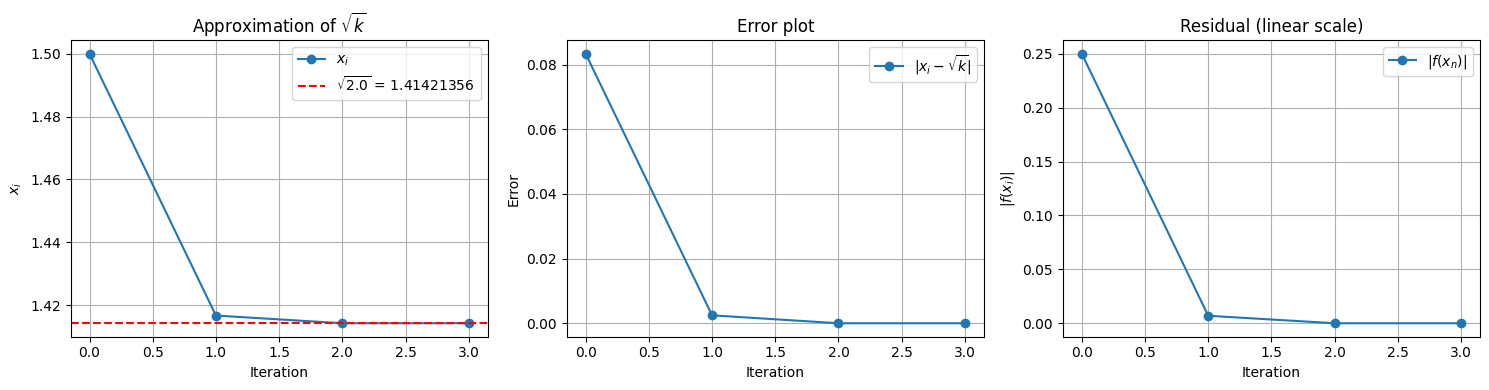

In [5]:
# Plot section
sqrt_k = np.sqrt(k)

plt.figure(figsize = (15, 4))

plt.subplot(1, 3, 1)
plt.plot(x, 'o-', label = '$x_i$')
plt.axhline(y = sqrt_k, color = 'r', linestyle = '--', label=r'$\sqrt{{{0}}}$ = {1:.8f}'.format(k, sqrt_k))
plt.xlabel('Iteration')
plt.ylabel('$x_i$')
plt.title(r'Approximation of $\sqrt{k}$')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(err, 'o-', label = r'$|x_i - \sqrt{k}|$')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Error plot')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(np.abs(fx), 'o-', label = '$|f(x_n)|$')
plt.xlabel('Iteration')
plt.ylabel('$|f(x_i)|$')
plt.title('Residual (linear scale)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

We got:

$$
    \sqrt{2} = 1.414213562375 \pm 0.000000000002
$$

While NumPy yields:

$$
    \sqrt{2}_{NumPy} = 1.414213562373...
$$

In [6]:
N = 30 # Max number of iterations (30)
tol = 1e-15 # Tolerance for fx (1e-15)
eps = 1e-12 # Maximum absolute error for x (1e-12)

for k in range(2, 101, 1): # We're going to find the root of all natural numbers between 2 and 100

    f = lambda x: x ** 2 - k # x^2 - k = 0
    x = k / 10.0 # Initial value of x (x0) as k / 10

    for j in range(N):
        x = 0.5 * (x + k / x) # Apply the formula
        fx = f(x)
        err = abs(fx / (2 * x))

        if abs(fx) < tol: # f(x) is very small, below 'tol'
            break
        elif err < eps: # the absolute error of x is smaller than 'eps'
            break

    print(f"\u221A{k} = {x:.12f}")

√2 = 1.414213562373
√3 = 1.732050807569
√4 = 2.000000000000
√5 = 2.236067977500
√6 = 2.449489742783
√7 = 2.645751311065
√8 = 2.828427124746
√9 = 3.000000000000
√10 = 3.162277660168
√11 = 3.316624790355
√12 = 3.464101615138
√13 = 3.605551275464
√14 = 3.741657386774
√15 = 3.872983346207
√16 = 4.000000000000
√17 = 4.123105625618
√18 = 4.242640687119
√19 = 4.358898943542
√20 = 4.472135955000
√21 = 4.582575694956
√22 = 4.690415759823
√23 = 4.795831523313
√24 = 4.898979485566
√25 = 5.000000000000
√26 = 5.099019513593
√27 = 5.196152422707
√28 = 5.291502622129
√29 = 5.385164807135
√30 = 5.477225575052
√31 = 5.567764362830
√32 = 5.656854249492
√33 = 5.744562646538
√34 = 5.830951894845
√35 = 5.916079783100
√36 = 6.000000000000
√37 = 6.082762530298
√38 = 6.164414002969
√39 = 6.244997998398
√40 = 6.324555320337
√41 = 6.403124237433
√42 = 6.480740698408
√43 = 6.557438524302
√44 = 6.633249580711
√45 = 6.708203932499
√46 = 6.782329983125
√47 = 6.855654600401
√48 = 6.928203230276
√49 = 7.000000000000
